In [1]:
# Data Handling & Math
import numpy as np
import pandas as pd

# Visualization Tools
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Scaling (Unsupervised)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
#music_df = pd.read_csv('C:/Users/DELL/AmazonMusicClustering/single_genre_artists.csv')
url = "https://github.com/vinodg-dotcom/AmazonMusicClustering/blob/main/single_genre_artists.csv?raw=true"
music_df = pd.read_csv(url)

In [3]:
music_df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [4]:
music_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [6]:
def display_null_entries(df):
    df_null = df.isnull().sum().sort_values(ascending = False)
    print(df_null)

display_null_entries(music_df)

id_songs              0
speechiness           0
name_artists          0
genres                0
followers             0
time_signature        0
tempo                 0
valence               0
liveness              0
instrumentalness      0
acousticness          0
mode                  0
name_song             0
loudness              0
key                   0
energy                0
danceability          0
release_date          0
id_artists            0
explicit              0
duration_ms           0
popularity_songs      0
popularity_artists    0
dtype: int64


In [7]:
duplicate_count = music_df.duplicated().sum()
print(f"Number of completely duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    music_df.drop_duplicates(inplace=True)

Number of completely duplicate rows: 0


In [8]:
columns_to_drop = ['id_songs', 'name_song', 'id_artists', 'name_artists', 'genres', 'release_date']

clustering_columns = music_df.drop(columns=columns_to_drop, axis=1)
print(clustering_columns.columns.tolist())

['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'popularity_artists']


In [9]:
output_file = "cleaned_clustering_features.csv"
clustering_columns.to_csv(output_file, index=False)

In [10]:
key_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'tempo', 'duration_ms']

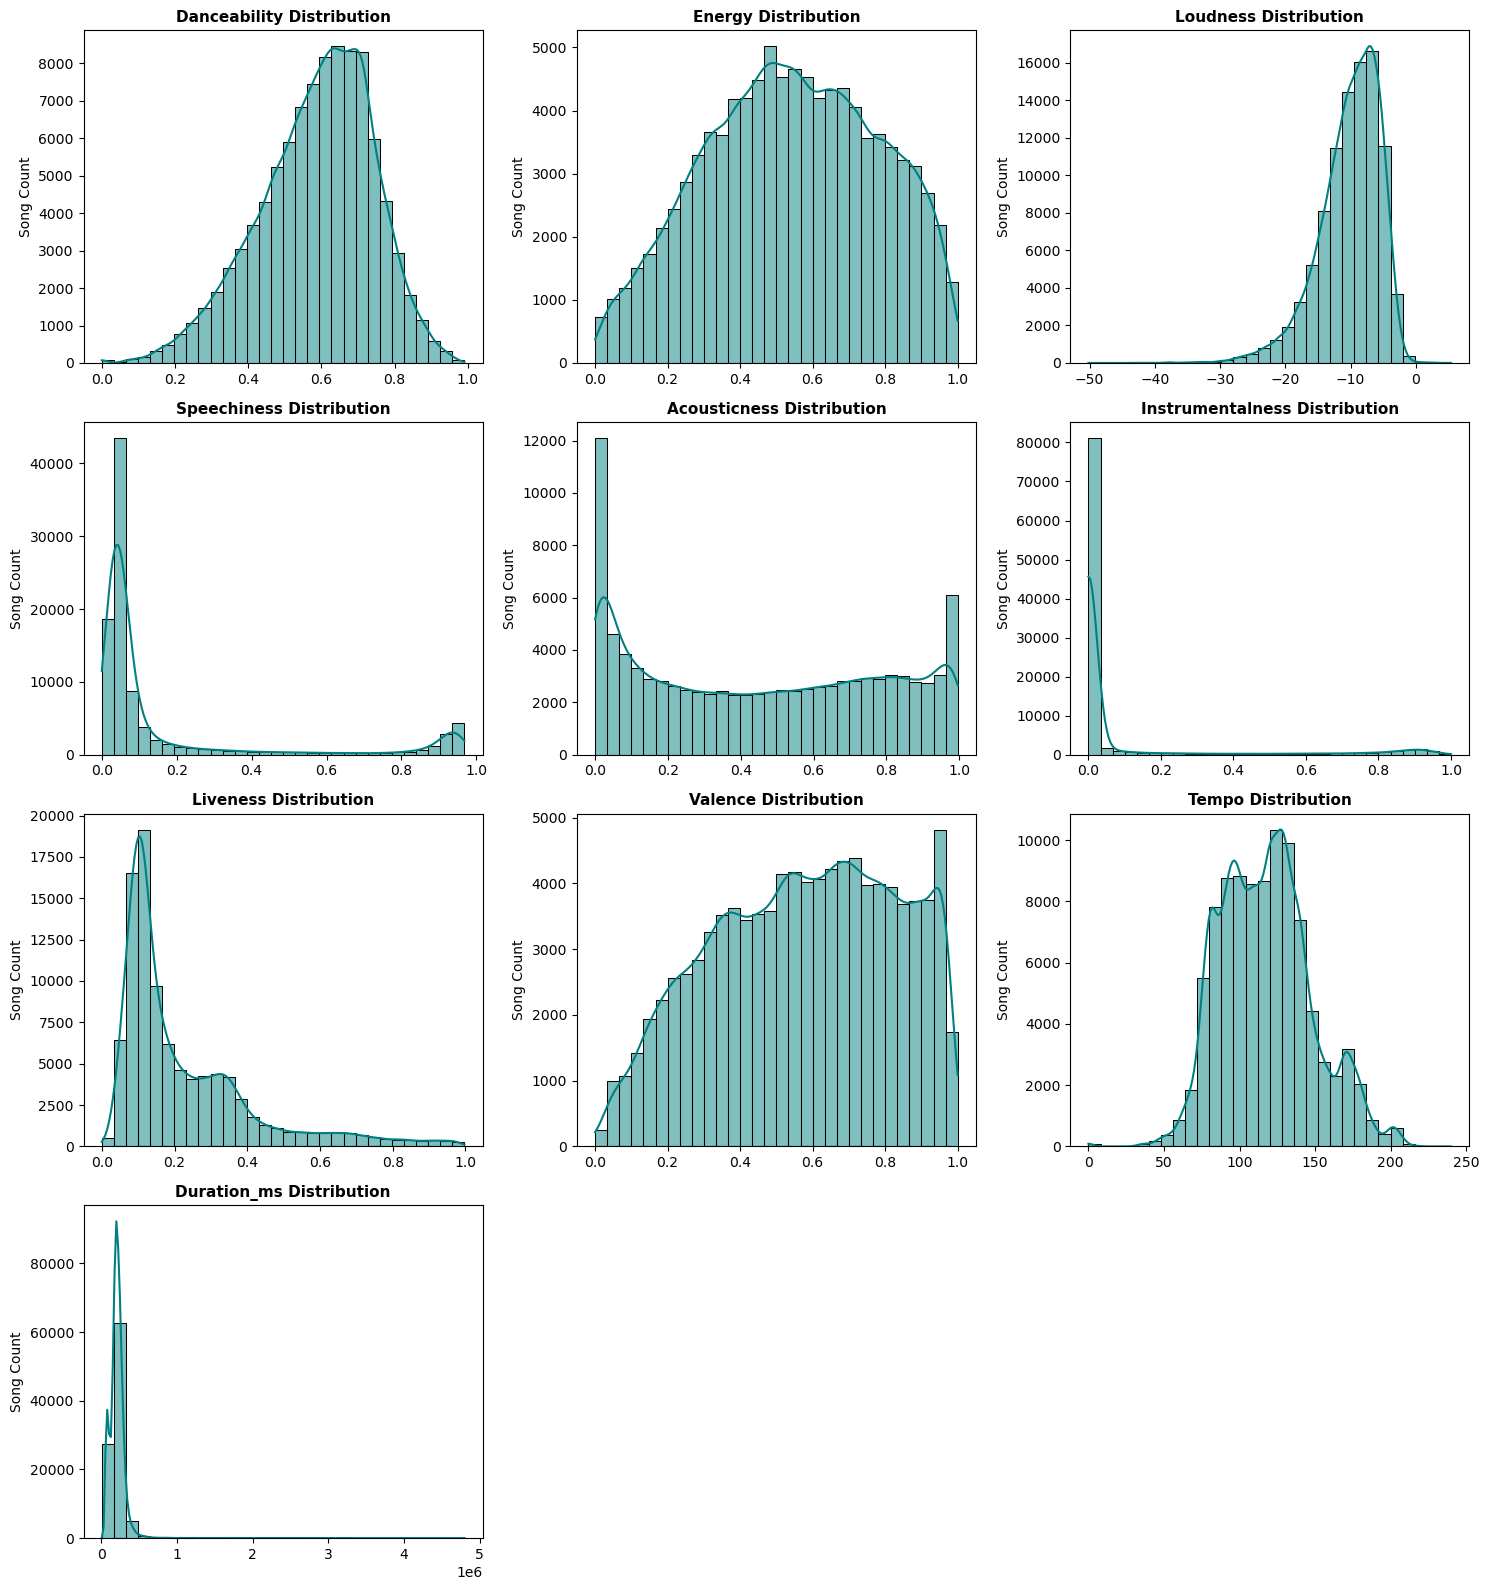

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16))
axes = axes.flatten()  

for i, feature in enumerate(key_features):
    sns.histplot(music_df[feature], ax=axes[i], kde=True, color='teal', bins=30)
    axes[i].set_title(f'{feature.capitalize()} Distribution', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Song Count')

for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
scaler = StandardScaler()

scaled_array = scaler.fit_transform(clustering_columns)
print(scaled_array)

X_scaled = pd.DataFrame(scaled_array, columns = clustering_columns.columns)
X_scaled.head()

[[-1.60368627 -0.40173462 -0.17478473 ... -1.56384556 -0.24708866
  -0.99624862]
 [-1.60368627  0.12490637 -0.17478473 ... -1.56384556 -0.24708866
  -0.99624862]
 [-1.60368627 -0.00394925 -0.17478473 ...  0.27302897 -0.24708866
  -0.99624862]
 ...
 [ 2.51836375 -1.07201656 -0.17478473 ...  0.27302897 -0.25356322
   0.43931441]
 [ 2.45684062 -0.19941949 -0.17478473 ... -1.56384556 -0.25347612
   0.58287072]
 [ 1.47247047  0.4206722  -0.17478473 ...  0.27302897 -0.25244506
  -0.230615  ]]


,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
0,-1.603686,-0.401735,-0.174785,-0.153476,-1.511128,-0.338561,-0.757909,0.736916,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,-1.563846,-0.247089,-0.996249
1,-1.603686,0.124906,-0.174785,-1.028518,-1.528056,1.358797,-1.098629,0.736916,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,-1.563846,-0.247089,-0.996249
2,-1.603686,-0.003949,-0.174785,-0.488051,-1.418027,-1.470134,-1.127899,0.736916,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,0.273029,-0.247089,-0.996249
3,-1.603686,-0.397437,-0.174785,0.573581,-0.313510,1.075904,-0.470677,-1.357007,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,0.273029,-0.247089,-0.996249
4,-1.603686,-0.346143,-0.174785,0.406294,-1.028695,1.075904,-0.768227,0.736916,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,0.273029,-0.247089,-0.996249


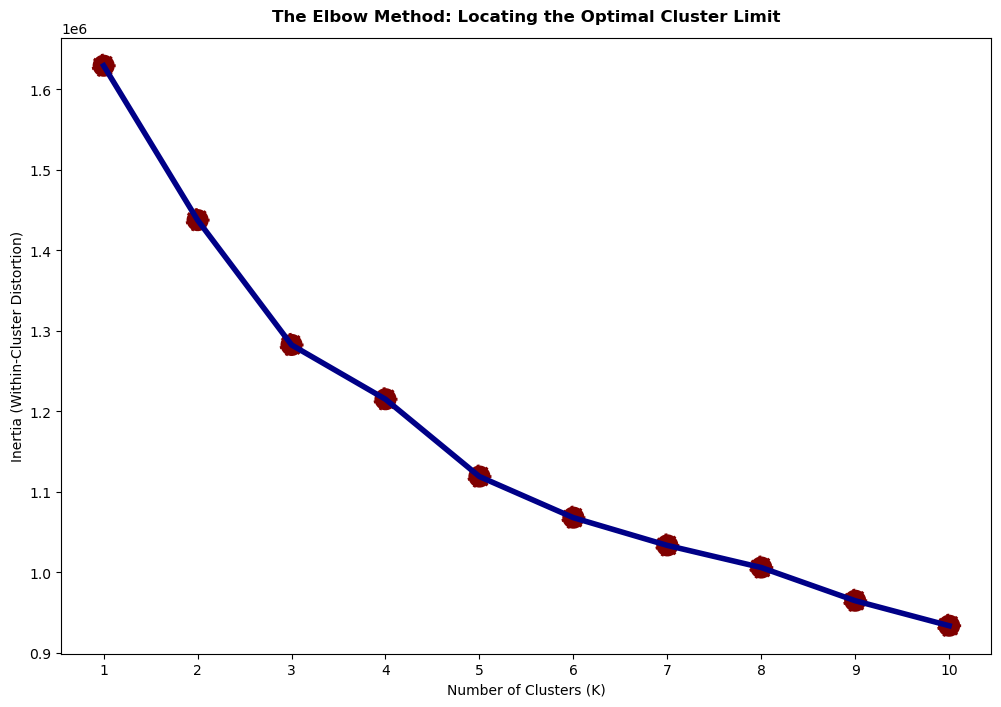

In [13]:
inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 8))
sns.lineplot(x=list(cluster_range), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=list(cluster_range), y=inertia, s=300, color='#800000',  linestyle='--')
plt.xticks(list(cluster_range))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Distortion)")
plt.title("The Elbow Method: Locating the Optimal Cluster Limit", fontsize=12, fontweight='bold', pad=12)
plt.savefig("kmeans_elbow_method_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
k_means = KMeans(n_clusters=4, n_init=10, random_state=42)
k_means.fit(X_scaled)
labels = k_means.labels_

In [15]:
music_df['Cluster_Label'] = labels
cluster_summary = music_df.groupby('Cluster_Label')[key_features].mean()
display(cluster_summary.round(3))

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
Cluster_Label,,,,,,,,,,
0,0.492,0.311,-13.376,0.073,0.759,0.171,0.188,0.440,112.068,219796.621
1,0.687,0.685,-7.078,0.197,0.245,0.027,0.202,0.537,118.442,211607.538
2,0.662,0.478,-13.128,0.836,0.566,0.001,0.435,0.581,100.343,89985.971
3,0.622,0.690,-7.640,0.067,0.260,0.050,0.199,0.658,124.971,230068.439


In [16]:
features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
radar_spokes = features + [features[0]]


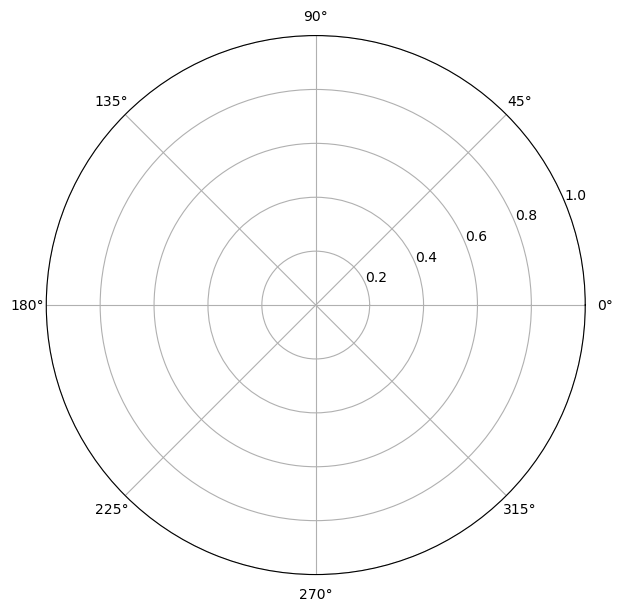

In [17]:
angles = np.linspace(start=0, stop=2 * np.pi, num=len(radar_spokes))
plt.figure(figsize=(7, 7))
ax = plt.subplot(polar=True)

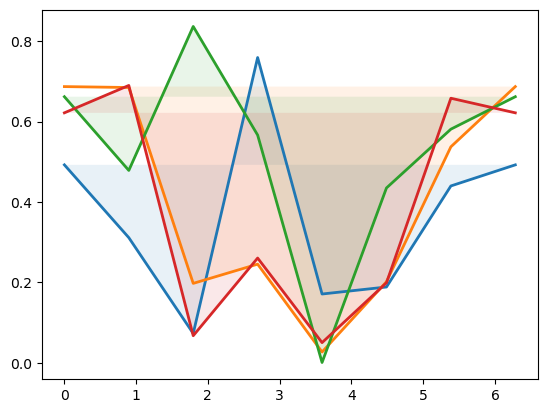

In [18]:
for i in range(0, 4):
    cluster_scores = cluster_summary.loc[i, features].tolist()
    
    closed_scores = cluster_scores + [cluster_scores[0]]
    
    plt.plot(angles, closed_scores, label=f'Cluster {i}', linewidth=2)
    
    plt.fill(angles, closed_scores, alpha=0.1)



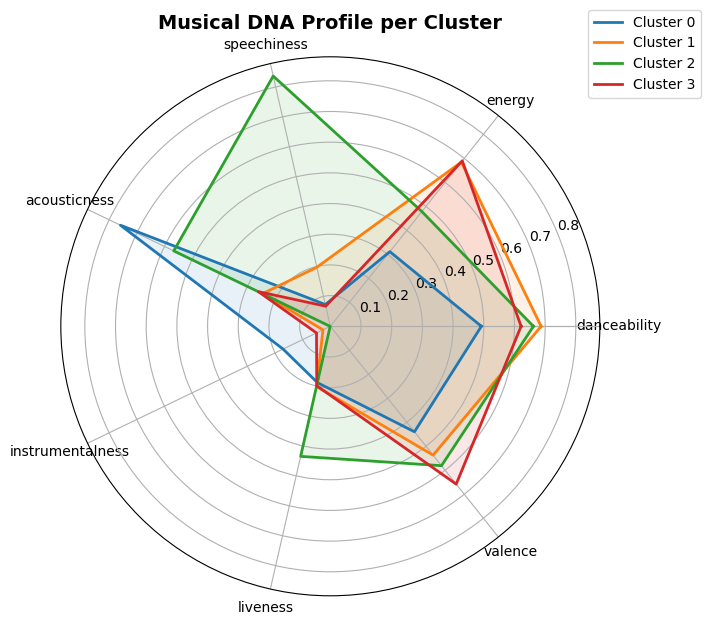

In [20]:
features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']

radar_spokes = features + [features[0]]

angles = np.linspace(start=0, stop=2 * np.pi, num=len(radar_spokes))

plt.figure(figsize=(7, 7))
ax = plt.subplot(polar=True)


for i in range(0, 4):
    cluster_scores = cluster_summary.loc[i, features].tolist()
    
    closed_scores = cluster_scores + [cluster_scores[0]]
    
    plt.plot(angles, closed_scores, label=f'Cluster {i}', linewidth=2)
    
    plt.fill(angles, closed_scores, alpha=0.1)


clean_labels = features + [""]
plt.thetagrids(np.degrees(angles), labels=clean_labels)


plt.title('Musical DNA Profile per Cluster', size=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1)) # Put the color legend on the side
plt.savefig("simple_music_radar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

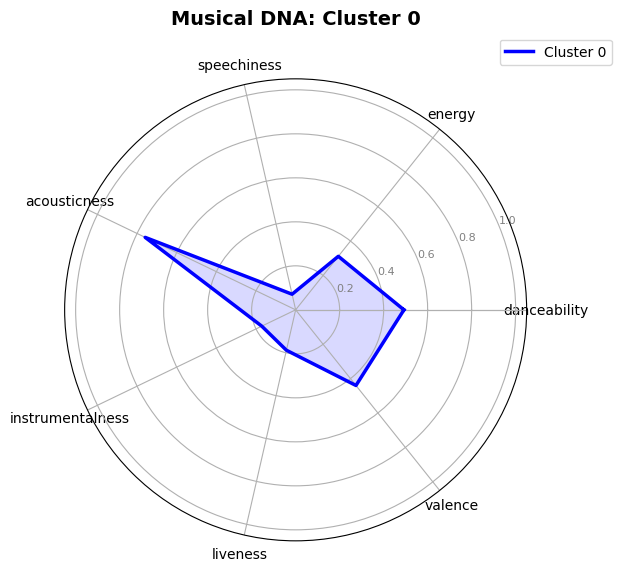

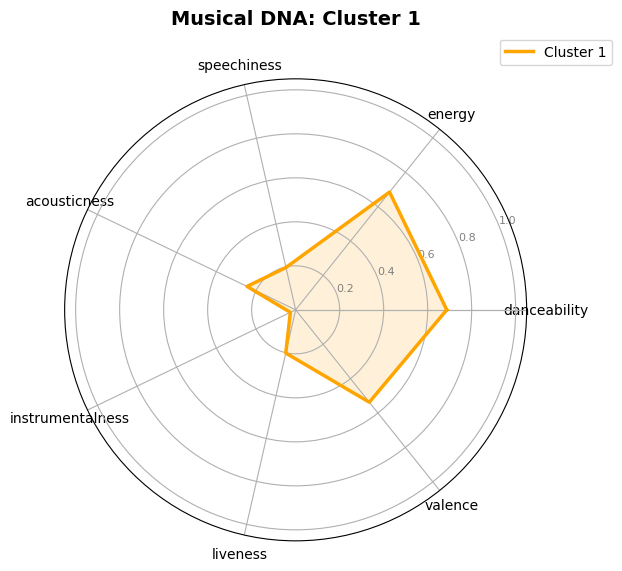

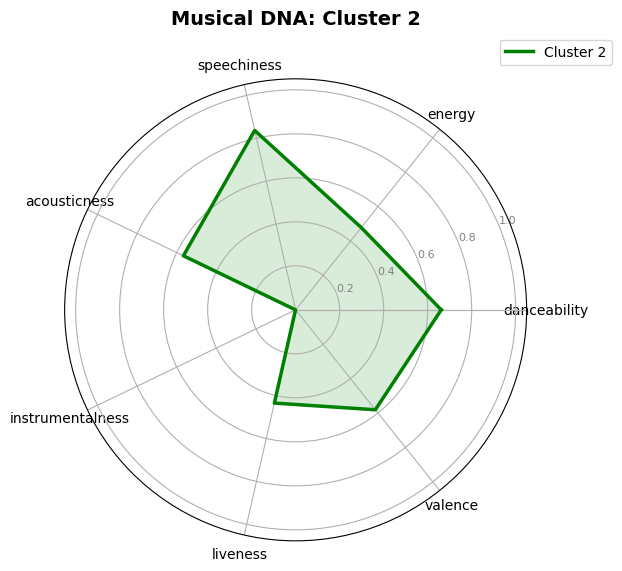

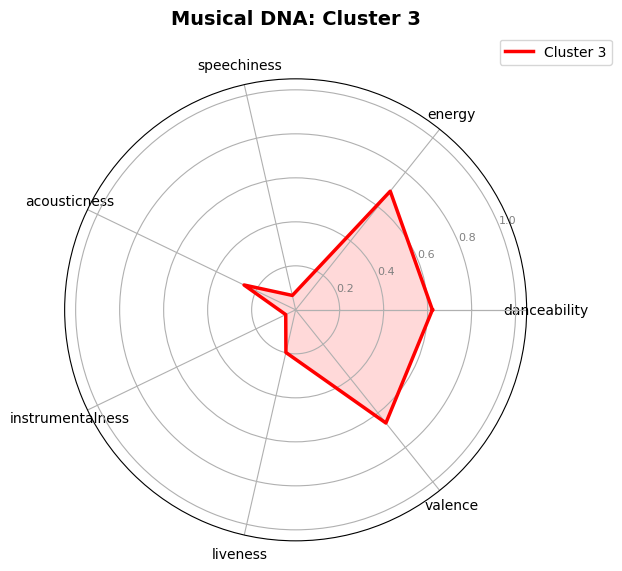

In [21]:
features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
radar_spokes = features + [features[0]]
clean_labels = features + [""] 
angles = np.linspace(start=0, stop=2 * np.pi, num=len(radar_spokes))


colors = ['blue', 'orange', 'green', 'red']


for i in range(0, 4):
    
    cluster_scores = cluster_summary.loc[i, features].tolist()
    closed_scores = cluster_scores + [cluster_scores[0]]
    
    plt.figure(figsize=(6, 6))
    plt.subplot(polar=True)
    
    lines, labels_objects = plt.thetagrids(np.degrees(angles), labels=clean_labels)
    
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
    plt.ylim(0, 1.05)
    
    plt.plot(angles, closed_scores, color=colors[i], label=f'Cluster {i}', linewidth=2.5)
    plt.fill(angles, closed_scores, color=colors[i], alpha=0.15)
    
    plt.title(f'Musical DNA: Cluster {i}', size=14, fontweight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    
    plt.savefig(f"music_radar_cluster_{i}.png", dpi=300, bbox_inches="tight")
    
    plt.show()

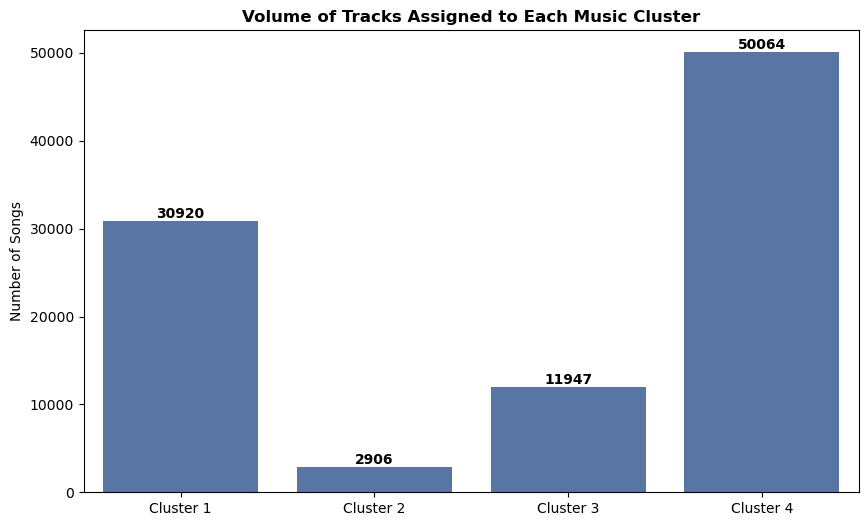

In [22]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x=labels, color='#4c72b0')

ax.bar_label(ax.containers[0], fontweight='bold')

plt.xticks([0, 1, 2, 3], ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4"])
plt.title("Volume of Tracks Assigned to Each Music Cluster", fontweight='bold')
plt.ylabel("Number of Songs")

plt.show()

In [23]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
model_inertia = k_means.inertia_
db_index = davies_bouldin_score(X_scaled, labels)

#sample_size = len(music_df) 
sample_size = 20000
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
sil_score = silhouette_score(X_scaled.iloc[sample_indices], labels[sample_indices])

sil_score = silhouette_score(X_scaled.iloc[sample_indices], labels[sample_indices])

print(f"Inertia (Lower = More Compact):       {model_inertia:.2f}")
print(f"Davies-Bouldin Index (Lower = Better): {db_index:.3f}")
print(f"Silhouette Score (Closer to 1 = Best): {sil_score:.3f}")

Inertia (Lower = More Compact):       1184986.01
Davies-Bouldin Index (Lower = Better): 1.784
Silhouette Score (Closer to 1 = Best): 0.172


In [24]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
data_pca = pd.DataFrame(data=pcs, columns=['PC 1', 'PC 2'])
data_pca['clusters'] = labels

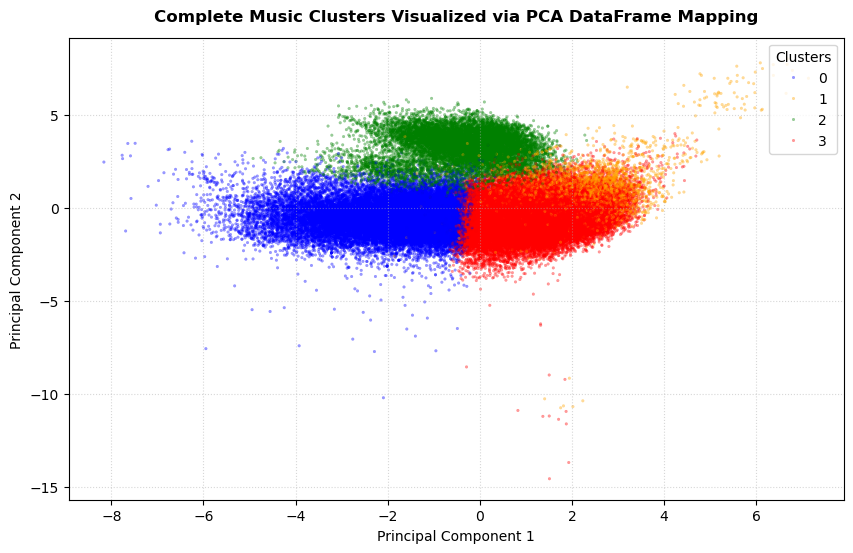

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x="PC 1", 
    y="PC 2",
    hue="clusters",
    data=data_pca,
    palette=['blue', 'orange', 'green', 'red'], 
    s=4,                         
    alpha=0.4,                   
    edgecolor=None,             
    ax=ax
)

plt.title('Complete Music Clusters Visualized via PCA DataFrame Mapping', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title="Clusters", loc='upper right')
plt.savefig("music_pca_dataframe_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

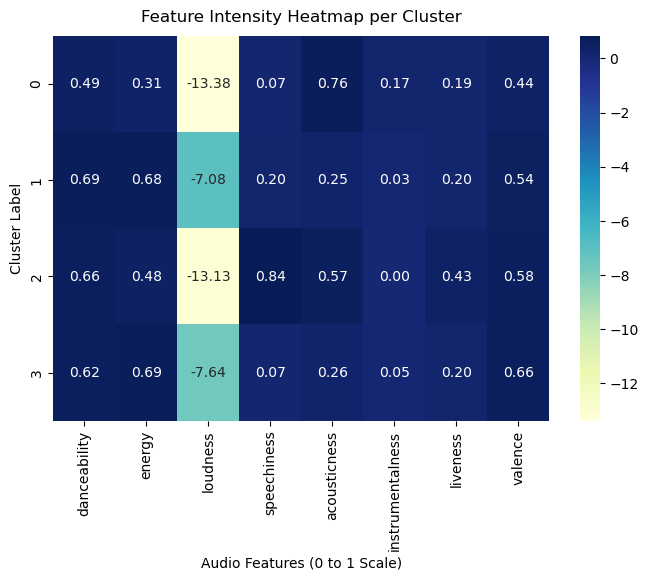

In [27]:
heatmap_features = []
for f in key_features:
    if f != "tempo" and f != "duration_ms":
        heatmap_features.append(f)

# 2. Plot the Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    cluster_summary[heatmap_features],
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    cbar=True,
)

plt.title("Feature Intensity Heatmap per Cluster", fontsize=12, pad=10)
plt.ylabel("Cluster Label")
plt.xlabel("Audio Features (0 to 1 Scale)")
plt.savefig("Feature Intensity Heatmap per Cluster.png", dpi=300, bbox_inches="tight")
plt.show()

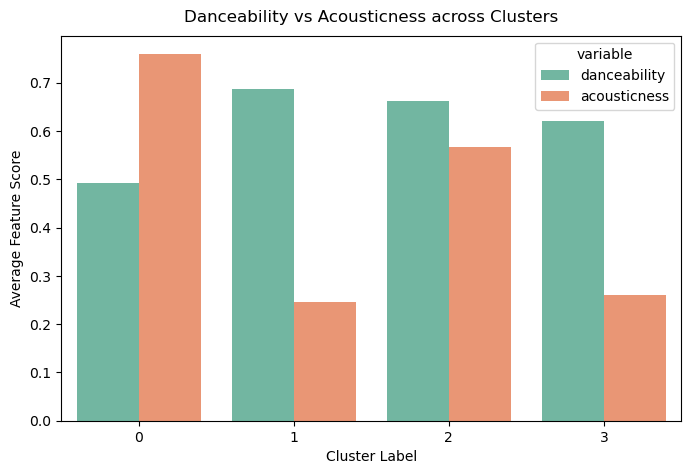

In [28]:
cluster_summary_melted = (
    cluster_summary[["danceability", "acousticness"]].reset_index().melt(id_vars="Cluster_Label")
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=cluster_summary_melted,
    x="Cluster_Label",
    y="value",
    hue="variable",
    palette="Set2",
)

plt.title("Danceability vs Acousticness across Clusters", fontsize=12, pad=10)
plt.ylabel("Average Feature Score")
plt.xlabel("Cluster Label")
plt.savefig("Danceability vs Acousticness across Clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
music_df["Cluster_Label"] = labels

print(music_df[["name_song", "name_artists", "Cluster_Label"]].head())

music_df.to_csv("final_clustered_music_dataset.csv", index=False)

          name_song name_artists  Cluster_Label
0           La Java  Mistinguett              0
1          En Douce  Mistinguett              0
2     J'en Ai Marre  Mistinguett              0
3  Ils n'ont pas ca  Mistinguett              0
4         La belote  Mistinguett              0
